C:\Users\mihre\AppData\Local\Temp\ipykernel_19252\4069340711.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("../data/BrentOilPrices.csv", parse_dates=["Date"])


✅ Data loaded — first few rows:
        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63


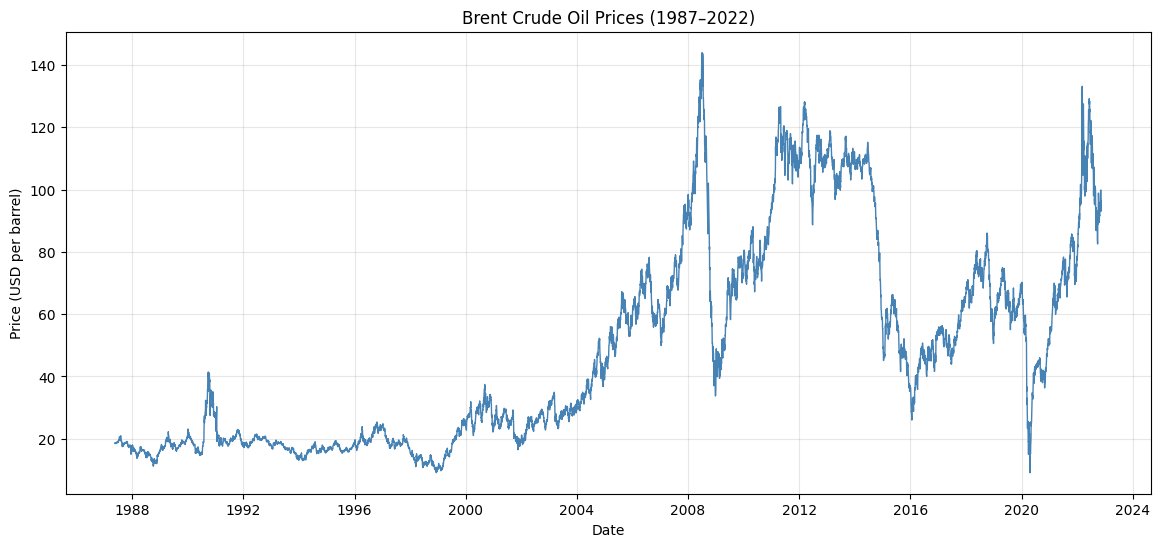

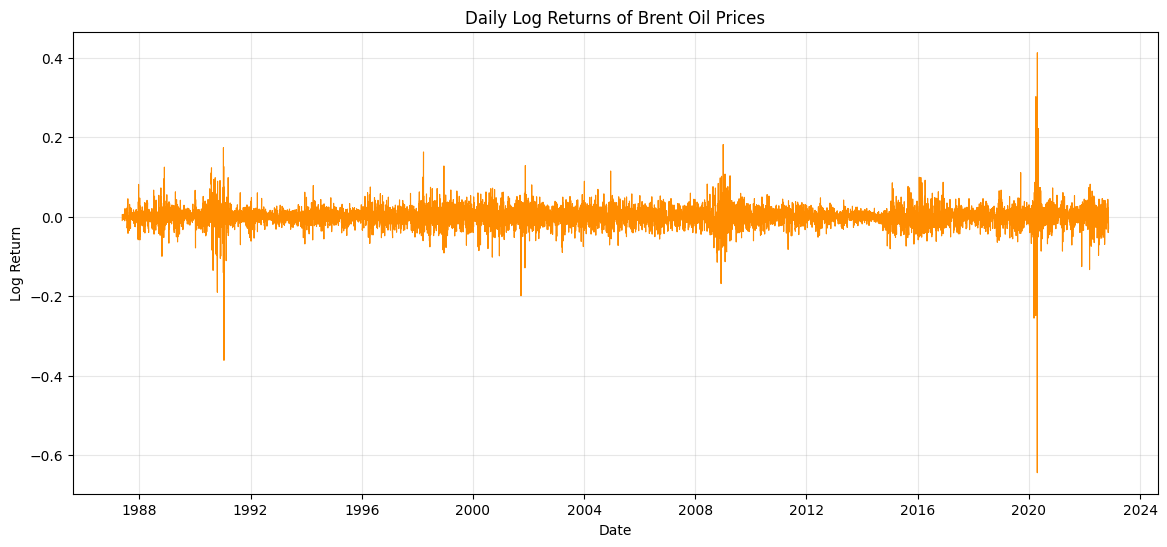


📌 Running Augmented Dickey-Fuller Tests:

--- ADF Raw Price Series ---
ADF Statistic: -1.9919
p-value: 0.2902

--- ADF Log Return Series ---
ADF Statistic: -16.4271
p-value: 0.0000

Monthly aggregated series (first few rows):
Date
1987-05-31    18.572857
1987-06-30    18.860476
1987-07-31    19.856522
1987-08-31    18.979524
1987-09-30    18.313182
Freq: ME, Name: Price, dtype: float64


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


c:\Users\mihre\Documents\KIAM\Week 11\Change Point Analysis and Statistical 
Modeling\venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 604 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



✅ Bayesian change point sampling complete!


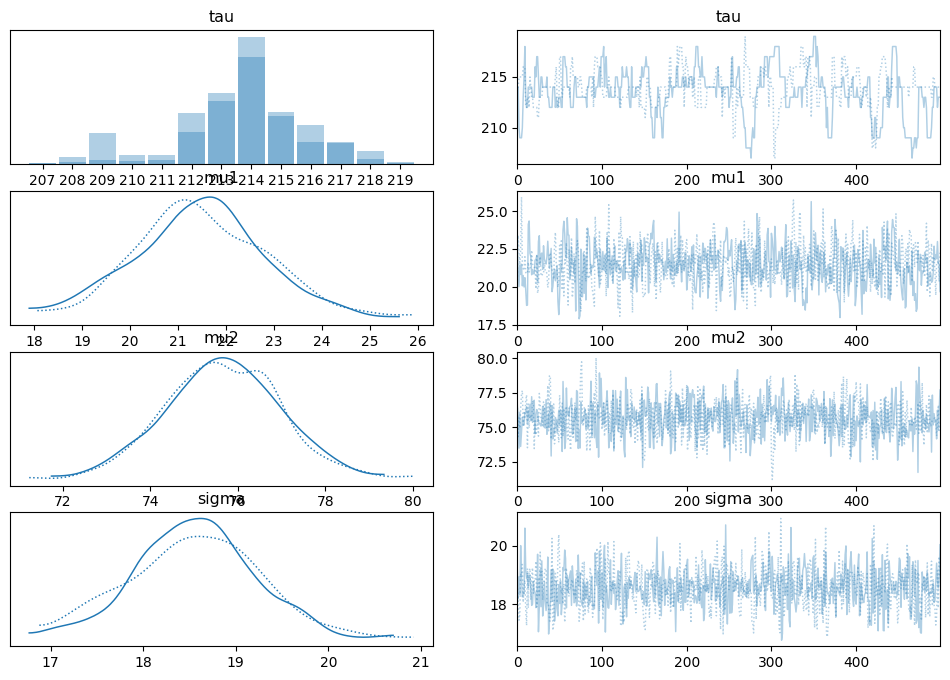

          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau    213.734  2.056  209.000  217.000      0.198    0.277     117.0   
mu1     21.473  1.343   19.025   24.097      0.050    0.041     729.0   
mu2     75.657  1.295   73.252   78.084      0.042    0.041     965.0   
sigma   18.565  0.685   17.264   19.828      0.022    0.021     945.0   

       ess_tail  r_hat  
tau        62.0   1.04  
mu1       576.0   1.00  
mu2       728.0   1.00  
sigma     626.0   1.00  

📍 Estimated change point date: 2005-03-31


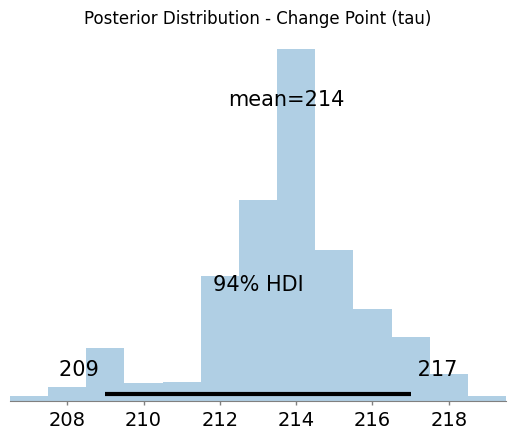

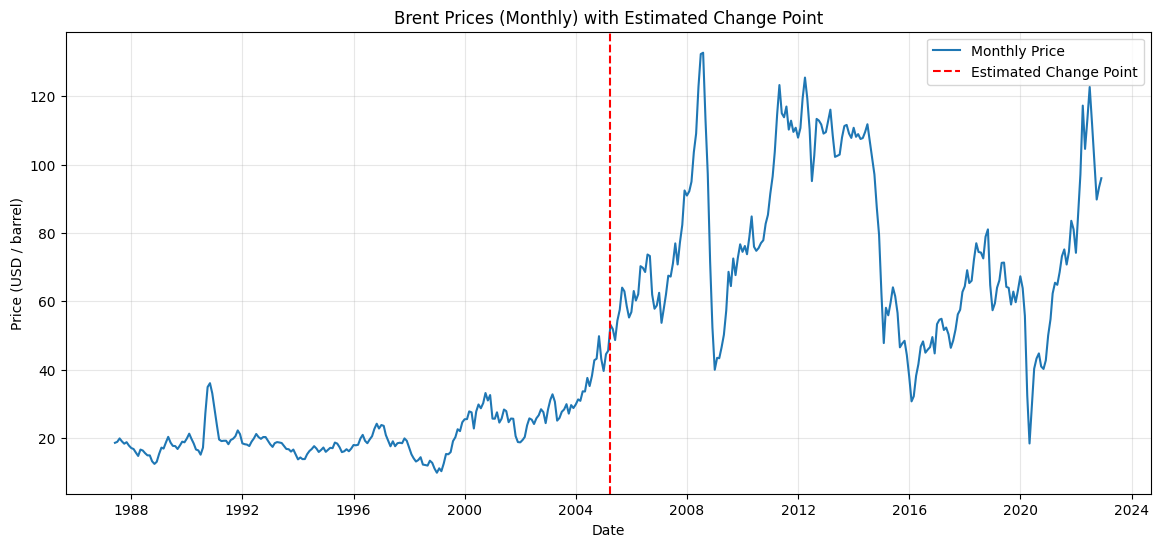

In [3]:
# ============================================================
# TASK 1 – COMPLETE TIME SERIES ANALYSIS & BAYESIAN CHANGE POINT
# ============================================================

# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as tsa

import pymc as pm
import arviz as az

# === 1️⃣ LOAD DATA ===
df = pd.read_csv("../data/BrentOilPrices.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("✅ Data loaded — first few rows:")
print(df.head())

# === 2️⃣ RAW PRICE TREND ===
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Price"], linewidth=1.0, color="steelblue")
plt.title("Brent Crude Oil Prices (1987–2022)")
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.grid(alpha=0.3)
plt.show()

# === 3️⃣ LOG RETURNS ===
df["log_return"] = np.log(df["Price"]).diff()
df = df.dropna()

plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["log_return"], linewidth=0.8, color="darkorange")
plt.title("Daily Log Returns of Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(alpha=0.3)
plt.show()

# === 4️⃣ AUGMENTED DICKEY-FULLER STATIONARITY TESTS ===
print("\n📌 Running Augmented Dickey-Fuller Tests:")

# ADF on raw price series
adf_price = tsa.adfuller(df["Price"])
print("\n--- ADF Raw Price Series ---")
print(f"ADF Statistic: {adf_price[0]:.4f}")
print(f"p-value: {adf_price[1]:.4f}")

# ADF on log returns series
adf_return = tsa.adfuller(df["log_return"])
print("\n--- ADF Log Return Series ---")
print(f"ADF Statistic: {adf_return[0]:.4f}")
print(f"p-value: {adf_return[1]:.4f}")

# === 5️⃣ DOWNSAMPLE DAILY TO MONTHLY (MONTH END) ===
# Use "ME" (month end) alias to avoid resample errors in newer pandas versions. :contentReference[oaicite:1]{index=1}
monthly = (
    df.set_index("Date")
      .resample("ME")["Price"]
      .mean()
      .dropna()
)

print("\nMonthly aggregated series (first few rows):")
print(monthly.head())

prices = monthly.values
dates = monthly.index
n = len(prices)

# === 6️⃣ BAYESIAN CHANGE POINT MODEL ===
with pm.Model() as cp_model:

    # Discrete uniform prior for change point index
    tau = pm.DiscreteUniform("tau", lower=0, upper=n - 1)

    # Regime means before and after
    mu1 = pm.Normal("mu1", mu=np.mean(prices), sigma=20)
    mu2 = pm.Normal("mu2", mu=np.mean(prices), sigma=20)

    # Shared noise term
    sigma = pm.HalfNormal("sigma", sigma=10)

    # Switch: before tau use mu1, after use mu2
    idx = np.arange(n)
    mu = pm.math.switch(idx < tau, mu1, mu2)

    # Observations
    pm.Normal("obs", mu=mu, sigma=sigma, observed=prices)

    # Sample from posterior (small draws for speed)
    trace = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        target_accept=0.9,
        return_inferencedata=True
    )

print("\n✅ Bayesian change point sampling complete!")

# === 7️⃣ TRACE PLOTS & SUMMARY ===
az.plot_trace(trace, var_names=["tau", "mu1", "mu2", "sigma"])
plt.show()

summary = az.summary(trace, var_names=["tau", "mu1", "mu2", "sigma"])
print(summary)

# === 8️⃣ CHANGE POINT INTERPRETATION ===
tau_samples = trace.posterior["tau"].values.flatten()
estimated_tau = int(np.median(tau_samples))
cp_date = dates[estimated_tau]

print(f"\n📍 Estimated change point date: {cp_date.date()}")

# Posterior of change point
az.plot_posterior(trace, var_names=["tau"])
plt.title("Posterior Distribution - Change Point (tau)")
plt.show()

# === 9️⃣ VISUALIZE CHANGE POINT ON PRICES ===
plt.figure(figsize=(14, 6))
plt.plot(dates, prices, label="Monthly Price")
plt.axvline(cp_date, linestyle="--", color="red", label="Estimated Change Point")
plt.title("Brent Prices (Monthly) with Estimated Change Point")
plt.xlabel("Date")
plt.ylabel("Price (USD / barrel)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
